In [23]:
import gymnasium as gym
import ale_py

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pyvirtualdisplay import Display

%matplotlib inline

In [8]:
env_name = "ALE/MsPacman-v5"

env = gym.make(env_name, render_mode="rgb_array")

### Exploring the environment

In [4]:
env.action_space

Discrete(9)

In [5]:
list(range(env.action_space.n))

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [6]:
env.observation_space

Box(0, 255, (210, 160, 3), uint8)

So the observation space is 210x160 3-channel array with values between 0-255 in RGB array mode

In [9]:
obs, info = env.reset()

In [12]:
info

{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

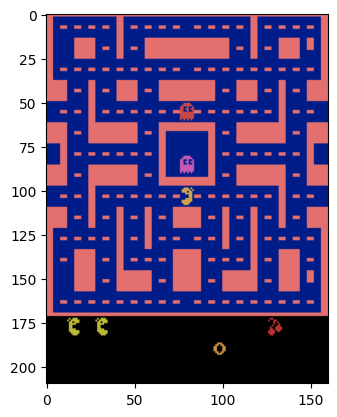

In [15]:
plt.imshow(obs)

### Reshaping the observation

In [19]:
env_64 = gym.wrappers.ResizeObservation(env, (84, 65))

obs, info  = env_64.reset()

plt.imshow(obs)

DependencyNotInstalled: opencv (cv2) is not installed, run `pip install "gymnasium[other]"`

### Recording and Evaluating rollouts

In [27]:
num_eval_eps = 5

env_rec = gym.wrappers.RecordVideo(
    env, 
    video_folder="./videos/examples/",
    name_prefix="test-video"
)
env_rec = gym.wrappers.RecordEpisodeStatistics(
    env_rec, buffer_length=num_eval_eps
)

rewards_hist = []

In [31]:
for ep_num in range(num_eval_eps):
    obs, info = env_rec.reset()
    ep_reward = 0
    step_count = 0
    
    while True:
        action = env_rec.action_space.sample()
        obs, reward, terminated, truncated, info= env_rec.step(action)
        
        ep_reward += float(reward)
        step_count += 1
        
        if (terminated or truncated): break
    
    print(f"Episode {ep_num + 1}: {step_count} steps, reward = {ep_reward}")

env_rec.close()

# Print summary statistics
print(f'\nEvaluation Summary:')
print(f'Episode durations: {list(env_rec.time_queue)}')
print(f'Episode rewards: {list(env_rec.return_queue)}')
print(f'Episode lengths: {list(env_rec.length_queue)}')

# Calculate some useful metrics
avg_reward = np.mean(env_rec.return_queue)
avg_length = np.sum(env_rec.length_queue)
std_reward = np.std(env_rec.return_queue)

print(f'\nAverage reward: {avg_reward:.2f} ± {std_reward:.2f}')
print(f'Average episode length: {avg_length:.1f} steps')
print(f'Success rate: {sum(1 for r in env_rec.return_queue if r > 0) / len(env_rec.return_queue):.1%}')


Episode 1: 485 steps, reward = 260.0
Episode 2: 429 steps, reward = 170.0
Episode 3: 421 steps, reward = 190.0
Episode 4: 447 steps, reward = 180.0
Episode 5: 461 steps, reward = 210.0

Evaluation Summary:
Episode durations: [0.237659, 0.102097, 0.100999, 0.166914, 0.216202]
Episode rewards: [260.0, 170.0, 190.0, 180.0, 210.0]
Episode lengths: [485, 429, 421, 447, 461]

Average reward: 202.00 ± 31.87
Average episode length: 2243.0 steps
Success rate: 100.0%
